In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys
import pyreadstat
import scipy.stats as st

In [3]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Phase 3 — Exploratory Data Analysis (EDA)

In this phase we will check if the merged Amsterdam–London dataset is analytically sound and suitable for discrete choice modelling. The objective is to idenitify distributional patterns, compare mode shares across the two cities, and test whether observed differences are statistically meaningful rather than descriptive noise.

The EDA is executed in the following sequence: 
1. Data integrity checks,
2. Univariate profiling
3. City-level mode comparisons
4. Categorical association tests
5. Continuous-variable group tests with assumptions.
  
The goal is to ensure that inputs for our model in Phase 4 are statistically defensible and transparently documented.

### 3.1 Build Joint Analysis Dataset (Amsterdam + London)

The first step constructs one tidy analysis dataset where each row is one commuting trip and each column is a harmonized variable. This enables direct city comparisons under identical variable definitions and avoids downstream inconsistencies in statistical testing.

The code below standardizes column names where needed, aligns data types, and creates a dataset with a city indicator. We will keep only the variables required for the EDA and the upcoming MNL estimation.

In [4]:
amst_data = pd.read_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\processed\amst_processed.csv")

In [5]:
amst_data.columns

Index(['new_id', 'person_id', 'trip_id', 'new_trip_id', 'home_municipality',
       'origin_municipality', 'dest_municipality', 'origin_postcode',
       'dest_postcode', 'amsterdam_neighborhood', 'trip_purpose',
       'mode_detailed', 'mode_class', 'mode_role', 'n_legs', 'month',
       'weekday', 'is_holiday', 'departure_hour', 'departure_minute',
       'travel_time_min', 'distance_hm', 'age', 'gender', 'income_decile',
       'has_driving_license', 'n_cars_household', 'weight_trip',
       'weight_person', 'distance_km', 'n_transfers', 'has_transfer',
       'is_peak', 'chosen_mode', 'city', 'age_band', 'income_quintile'],
      dtype='object')

In [6]:
lnd_data = pd.read_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\processed\lnd_processed.csv")

In [7]:
lnd_data.columns

Index(['person_id', 'trip_id', 'trip_purpose', 'mode_detailed',
       'travel_time_min', 'distance_km', 'departure_hour', 'weekday',
       'is_holiday', 'age_band', 'gender', 'income_quintile',
       'has_driving_license', 'n_cars_household', 'weight_trip',
       'weight_person', 'city', 'is_peak', 'chosen_mode', 'n_transfers',
       'has_transfer', 'n_legs'],
      dtype='object')

In [8]:
# Keep common columns only (defensive alignment)
shared_columns = [
    "person_id", "trip_id", "trip_purpose", "mode_detailed",
    "travel_time_min", "distance_km", "departure_hour",
    "n_legs", "n_transfers","has_transfer","weekday", "is_holiday",
    "age_band", "gender", "income_quintile", "has_driving_license",
    "n_cars_household", "weight_trip", "weight_person", "city",
    "is_peak", "chosen_mode"
]

In [9]:
# Keep only needed columns for both datasets
amst_data = amst_data[[c for c in shared_columns if c in amst_data.columns]].copy()
lnd_data = lnd_data[[c for c in shared_columns if c in lnd_data.columns]].copy()

combined_data = pd.concat([amst_data, lnd_data], ignore_index = True) #Union both datasets

In [10]:
# Basic harmonization
combined_data["chosen_mode"] = combined_data.chosen_mode.astype("category")
combined_data["city"] = combined_data.city.astype("category")

In [11]:
combined_data.city.value_counts() #Londons dataset is much bigger than Amsterdams dataset

city
London       3315
Amsterdam     681
Name: count, dtype: int64

### 3.2 Data integrity checks

In this step we will verify data quality and structural integrity. This includes duplicate checks, missingness, invalid ranges, and category support by city. These checks protect against silent data issues that can bias statistical tests and model coefficients.

The goal is to do quick diagnostics and validation, not exhaustive auditing.

In [12]:
# Duplicate rows check
combined_data.duplicated(subset=["city", "trip_id"]).sum()

np.int64(0)

In [15]:
#Missing values
combined_data.isna().sum()

person_id              0
trip_id                0
trip_purpose           0
mode_detailed          0
travel_time_min        0
distance_km            0
departure_hour         0
n_legs                 0
n_transfers            0
has_transfer           0
weekday                0
is_holiday             0
age_band               0
gender                 0
income_quintile        0
has_driving_license    0
n_cars_household       0
weight_trip            0
weight_person          0
city                   0
is_peak                0
chosen_mode            0
dtype: int64

In [25]:
# Check Invalid 
invalid_ranges = {
    "negative_time": (combined_data.travel_time_min <= 0).sum(),
    "negative_dist": (combined_data.distance_km <= 0).sum(),
    "invalid_hour": (~combined_data.departure_hour.between(0, 23)).sum(),
}

In [26]:
invalid_ranges #29 records in London sets which we flagged during the dataload (-1 hour) 

{'negative_time': np.int64(0),
 'negative_dist': np.int64(0),
 'invalid_hour': np.int64(29)}

In [37]:
# Relationship/Logic checks
logic_errors = {
    "underage_commuters": (combined_data.age_band <= 3).sum(),  #Underage commuters are people in age band 1,2 and 3 (0-16 years old) 
    "transfer_mismatch": (combined_data.n_transfers != (combined_data.n_legs - 1)).sum(), # Transfer logic: n_transfers should usually be n_legs - 1
    "underage_driver": ((combined_data.age_band <= 3) & (combined_data.has_driving_license == True)).sum() # License check: if < 16-18 (depending on city), has_driving_license should be False
}

In [54]:
logic_errors #we see that we have 35 trips which have more than 1 legs but no transfers

{'underage_commuters': np.int64(0),
 'transfer_mismatch': np.int64(35),
 'underage_driver': np.int64(0)}

In [55]:
combined_data[combined_data.n_transfers != (combined_data.n_legs - 1)][["chosen_mode","city"]].value_counts().sort_index()

chosen_mode  city     
bike         Amsterdam    22
             London        2
car          Amsterdam     5
             London        6
Name: count, dtype: int64

In [56]:
combined_data[combined_data.n_transfers != (combined_data.n_legs - 1)]

,person_id,trip_id,trip_purpose,mode_detailed,travel_time_min,distance_km,departure_hour,n_legs,n_transfers,has_transfer,...,age_band,gender,income_quintile,has_driving_license,n_cars_household,weight_trip,weight_person,city,is_peak,chosen_mode
49,2.708820e+11,2.708820e+13,1.0,8.0,30.0,2.500000,22.0,2.0,0,0,...,6,2.0,5,0.0,0.0,166071.066206,454.989222,Amsterdam,0,bike
74,2.713987e+11,2.713987e+13,1.0,8.0,45.0,12.000000,8.0,3.0,0,0,...,7,1.0,5,1.0,1.0,64594.869619,176.972246,Amsterdam,1,bike
75,2.713987e+11,2.713987e+13,1.0,8.0,45.0,11.000000,16.0,3.0,0,0,...,7,1.0,5,1.0,1.0,64594.869619,176.972246,Amsterdam,0,bike
129,2.720820e+11,2.720820e+13,1.0,1.0,80.0,25.200000,6.0,3.0,0,0,...,7,2.0,2,1.0,1.0,175943.997410,482.038349,Amsterdam,0,car
130,2.720820e+11,2.720820e+13,1.0,1.0,73.0,24.700000,21.0,3.0,0,0,...,7,2.0,2,1.0,1.0,175943.997410,482.038349,Amsterdam,0,car
154,2.724720e+11,2.724720e+13,1.0,1.0,30.0,7.400000,8.0,2.0,0,0,...,6,1.0,5,1.0,1.0,56311.672961,154.278556,Amsterdam,1,car
155,2.724720e+11,2.724720e+13,1.0,1.0,30.0,7.400000,17.0,2.0,0,0,...,6,1.0,5,1.0,1.0,56311.672961,154.278556,Amsterdam,1,car
158,2.725720e+11,2.725720e+13,1.0,8.0,25.0,4.000000,8.0,3.0,0,0,...,9,1.0,3,1.0,1.0,38794.474756,106.286232,Amsterdam,1,bike
159,2.725720e+11,2.725720e+13,1.0,8.0,30.0,3.500000,13.0,3.0,0,0,...,9,1.0,3,1.0,1.0,38794.474756,106.286232,Amsterdam,0,bike
166,2.726030e+11,2.726030e+13,1.0,8.0,23.0,1.700000,7.0,3.0,0,0,...,9,2.0,3,1.0,0.0,83413.060883,228.528934,Amsterdam,1,bike


### 3.3 Descriptive Univariate EDA

In this step we are going to check the distributions of key behavioural and socioeconomic variables. This will set the baseline context and helps detect asymmetry, concentration, or sparse categories that may affect test validity and model stability.

We inspect central tendency and spread for continuous variables, and frequency distributions for categorical variables.

In [71]:
combined_data.groupby("city").travel_time_min.describe().T.round(2)

C:\Users\vladimir.koev\AppData\Local\Temp\ipykernel_28116\1462392510.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_data.groupby("city").travel_time_min.describe().T.round(2)


city,Amsterdam,London
count,681.00,3315.00
mean,27.89,36.72
std,15.88,18.65
min,2.00,5.00
25%,15.00,25.00
50%,25.00,30.00
75%,35.00,45.00
max,120.00,120.00


Firstly, we need to mention that the Londons' sample is much bigger than the Amsterdam data. Apart from that we see very interesting and distinct differences between both city commuters. 

Londoners travel longer: The mean travel time in London (36.72 min) which is more with 8 mins (nearly 30%) longer than in Amsterdam. 25% of Amsterdam commuters reach their destination in just 15 mins while in London even the "quick" commuters spend 25mins. We can say that there is actually no "quick" commuters in London as the 50% quartile is just 5mins longer than the 25% compared to Amsterdam where the difference is 10 mins (+50% longer trip). However, the "typical" journey for both cities is about 30 mins      

London has a higher standard deviation (18.65), suggesting more unpredictable traffic or wider geographical dispersion compared to Amsterdam.  


In [72]:
combined_data.groupby("city").distance_km.describe().T.round(2)

C:\Users\vladimir.koev\AppData\Local\Temp\ipykernel_28116\3938683810.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_data.groupby("city").distance_km.describe().T.round(2)


city,Amsterdam,London
count,681.00,3315.00
mean,9.83,11.24
std,10.30,7.83
min,0.20,0.32
25%,3.00,4.83
50%,6.00,9.66
75%,12.00,16.09
max,50.00,48.28


In line with our comment that London commuters do not have 'short trips' in terms of travel time, we see that they cover much longer distances compared to Amsterdam commuters. In London the bottom 25% distnaces extends to nearly 5 km compared to 3km in Amsterdam.This is a significant jump; 5 km is on the edge of what many people consider a "short" or walkable trip, forcing a higher reliance on motorized transport early on.

While  Amsterdam has a "short-trip" profile where 50% of the commuting trips are 6 km or less (very bike-friendly distances), the "typical" trip in London is over 60% longer being almost 10kms. Generally, in London, more than 50% of trips are longer than 9.66 km, moving the typical trip into the territory where cars or public transit become much more attractive than active travel.   

Lastly, to mention that Amsterdam’s trip distance has a standard deviation (10.30) higher than its mean (9.83) indicatating a high right-skewness of the data. Most people are making very short trips (under 6 km), but a few people traveling 50 km are inflating the "average.In London, the Mean (11.24) and Median (9.66) are much closer. This suggests London trip distances are more "normally distributed" or evenly spread across the population.

In [78]:
# Categorical frequency snapshots
for variable in ["chosen_mode", "age_band", "income_quintile", "gender", "has_driving_license"]:
    freq_table = (combined_data[variable].value_counts(dropna = False).sort_index().to_frame("count") .assign(pct = lambda x: (x["count"] / x["count"].sum() * 100).round(1))
    )
    print(f"\nFrequency — {variable}")
    print(freq_table.head(10))


Frequency — chosen_mode
             count   pct
chosen_mode             
bike           690  17.3
car           1431  35.8
pt            1875  46.9

Frequency — age_band
          count   pct
age_band             
4            72   1.8
5           857  21.4
6          1044  26.1
7           801  20.0
8           806  20.2
9           416  10.4

Frequency — income_quintile
                 count   pct
income_quintile             
1                  601  15.0
2                  582  14.6
3                  534  13.4
4                  895  22.4
5                 1384  34.6

Frequency — gender
        count   pct
gender             
1.0      2036  51.0
2.0      1960  49.0

Frequency — has_driving_license
                     count   pct
has_driving_license             
0.0                   1038  26.0
1.0                   2958  74.0


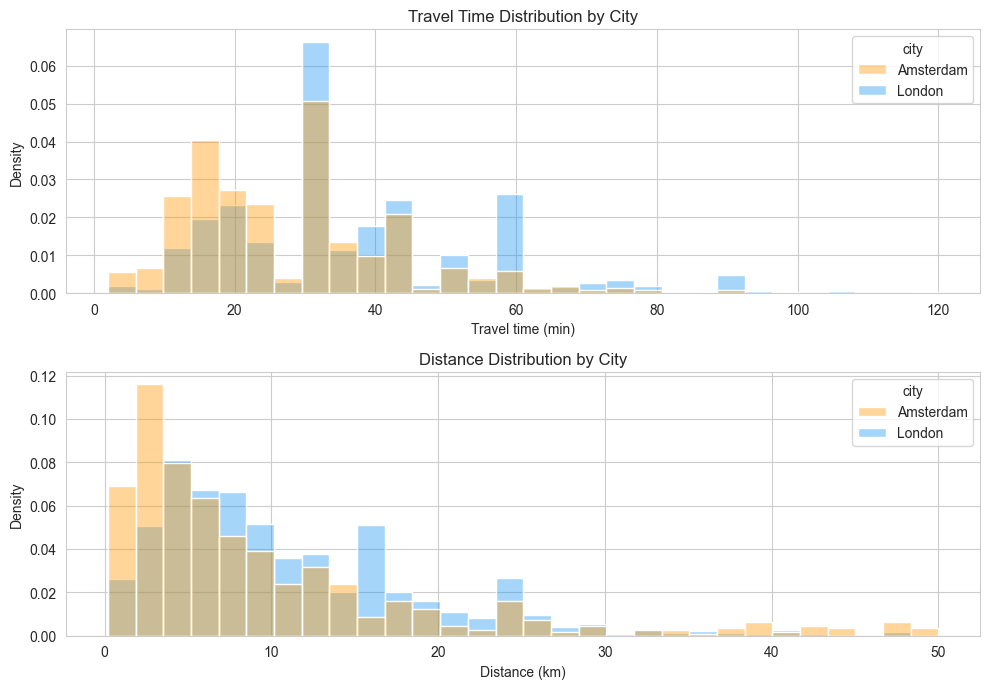

In [100]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

city_colors = {"Amsterdam": "#FF9800", "London": "#2196F3"}

# Plot 1: Travel Time
sns.histplot(
    data = combined_data, x = "travel_time_min", hue = "city",
    bins = 30, stat = "density", common_norm = False, 
    palette = city_colors,
    alpha = 0.4, # Transparency (0 is clear, 1 is solid),
    # fill = True,
    ax = axes[0]
)
axes[0].set_title("Travel Time Distribution by City")
axes[0].set_xlabel("Travel time (min)")
axes[0].set_ylabel("Density")

# Plot 2: Distance
sns.histplot(
    data = combined_data, x = "distance_km", hue = "city",
    bins = 30, stat = "density", common_norm=False,
    palette = city_colors,
    alpha=0.4,
    # fill=True,
    ax=axes[1]
)
axes[1].set_title("Distance Distribution by City")
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

### 3.4 Mode-Share Baseline: Amsterdam vs London

Mode share is the core descriptive result for this project. We compute both unweighted and survey-weighted city-level shares to separate sample composition effects from population-representative patterns.

This comparison provides the empirical baseline that motivates the city-specific MNL models in Phase 4.

In [102]:
# Unweighted mode share
mode_share_unweighted = (
    pd.crosstab(combined_data.city, combined_data.chosen_mode, normalize="index").mul(100).round(1))

In [103]:
mode_share_unweighted

chosen_mode,bike,car,pt
city,,,
Amsterdam,59.8,26.4,13.8
London,8.5,37.7,53.7


In [ ]:
# Weighted mode share using trip weights
weighted_counts = (
    combined_data.groupby(["city", "chosen_mode"], observed=False).weight_trip.sum().rename("weighted_sum").reset_index().round(0)
)

In [114]:
weighted_totals = weighted_counts.groupby("city").weighted_sum.transform("sum")
weighted_counts["weighted_pct"] = (weighted_counts.weighted_sum / weighted_totals * 100).round(1)

mode_share_weighted = weighted_counts.pivot(index="city", columns="chosen_mode", values="weighted_pct").fillna(0)

C:\Users\vladimir.koev\AppData\Local\Temp\ipykernel_28116\690805049.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weighted_totals = weighted_counts.groupby("city").weighted_sum.transform("sum")


In [118]:
weighted_counts

,city,chosen_mode,weighted_sum,weighted_pct
0,Amsterdam,bike,48648265.0,60.1
1,Amsterdam,car,19790012.0,24.4
2,Amsterdam,pt,12511701.0,15.5
3,London,bike,353.0,9.4
4,London,car,1270.0,33.7
5,London,pt,2151.0,57.0


In [115]:
mode_share_weighted

chosen_mode,bike,car,pt
city,,,
Amsterdam,60.1,24.4,15.5
London,9.4,33.7,57.0


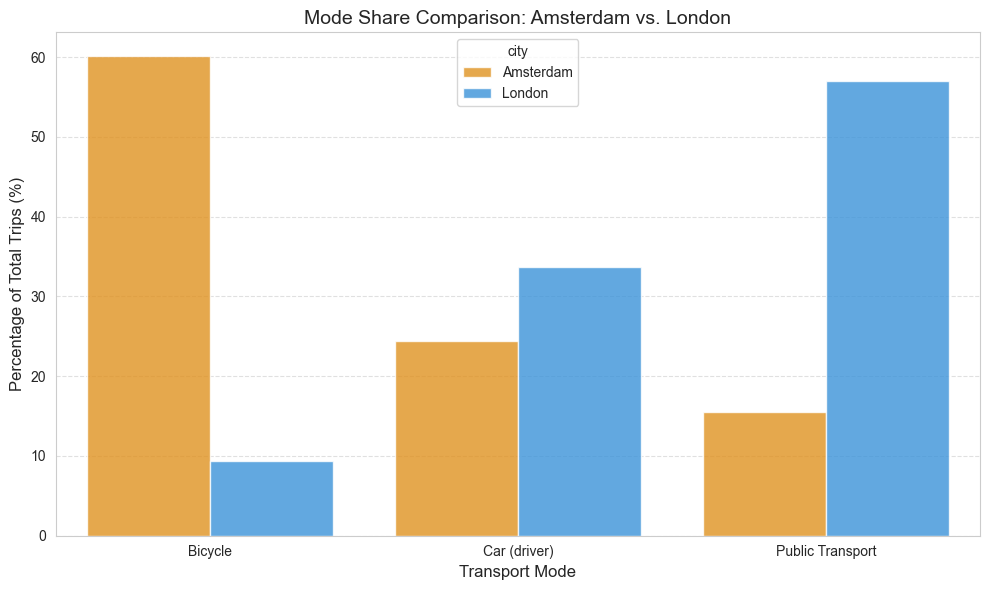

In [124]:
city_colors = {"Amsterdam": "#FF9800", "London": "#2196F3"}

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(
    data = weighted_counts, 
    x = "chosen_mode", 
    y = "weighted_pct", 
    hue="city",
    palette = city_colors, # Using your city colors
    alpha=0.8
)

# 3. Customizing the layout
plt.title("Mode Share Comparison: Amsterdam vs. London", fontsize=14)
plt.xlabel("Transport Mode", fontsize=12)
plt.ylabel("Percentage of Total Trips (%)", fontsize=12)

# Use your custom labels for the x-axis ticks
plt.xticks(
    ticks=[0, 1, 2], 
    labels=[mode_labels.get(x, x) for x in mode_share_perc['chosen_mode'].unique()]
)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### 3.5 Cross-tabs and Chi-Squared Tests (Categorical Association)

We now test whether mode choice is statistically associated with city and socioeconomic factors. For each test, null hypothesis is independence between variables; the alternative is association.

For all tests we use significance level \(\alpha = 0.05\). We report \(\chi^2\), degrees of freedom, p-value, and check expected cell counts to validate test assumptions.

### 5. Continuous-variable group tests with assumptions.